In [44]:
import torch
import sqlite3

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.metrics import roc_auc_score, average_precision_score

from typing import cast, TypedDict

from pathlib import Path

ROOT = Path.cwd().parents[1]

EMBED_PATH = ROOT / "data/embeddings/dino_layers_embeds"
EMBED_NAME = EMBED_PATH.stem

IMAGE_DIR = ROOT / "images/baseline" / EMBED_NAME
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [45]:
IMAGE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

conn = sqlite3.connect(ROOT / "data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn) # pyright: ignore[reportUnknownMemberType]

conn.close()

In [46]:
layer_paths = sorted(EMBED_PATH.glob("layer_*_cls.pt"))

class LayerResults(TypedDict):
    layer: str
    category: str
    auroc: float
    auprc: float

In [47]:
layer_results: list[LayerResults] = []

for path in tqdm(layer_paths):
    cls_tokens = torch.load(path, weights_only=True).numpy()

    layer_name = path.stem.removesuffix("_cls")

    for category in meta["category"].unique():
        train_mask = (
            (meta["category"] == category)
            & (meta["split"] == "train")
        )

        test_mask = (
            (meta["category"] == category)
            & (meta["split"] == "test")
        )

        train_cls = cls_tokens[train_mask]
        test_cls = cls_tokens[test_mask]

        labels = cast(
            pd.Series,
            meta.loc[test_mask, "label"]
            ).to_numpy(dtype=np.int64)

        centroid = train_cls.mean(axis=0)

        covariance = np.cov(train_cls.T)
        covariance += np.eye(covariance.shape[0]) * 1e-6
        covariance_inv = np.linalg.pinv(covariance)

        diff = test_cls - centroid

        scores = np.sqrt(
            np.einsum(
                "ij,jk,ik->i",
                diff,
                covariance_inv,
                diff,
            )
        )

        layer_results.append(
            {
                "layer": layer_name,
                "category": category,
                "auroc": float(roc_auc_score(labels, scores)),
                "auprc": float(average_precision_score(labels, scores)),
            }
        )

layer_df = pd.DataFrame(layer_results)
layer_df.to_csv(RESULTS_DIR / "layer_stats.csv")

  0%|          | 0/12 [00:00<?, ?it/s]

In [48]:
layer_summary = (
    layer_df
    .groupby("layer")[["auroc", "auprc"]]
    .agg(["mean", "median", "std"])
)

layer_summary.to_csv(RESULTS_DIR / "layer_summary.csv")
layer_summary

auroc                         auprc                    
              mean    median       std      mean    median       std
layer                                                               
layer_01  0.638901  0.640762  0.197928  0.823052  0.887905  0.129359
layer_02  0.677283  0.706408  0.206311  0.843617  0.900259  0.125363
layer_03  0.740600  0.742913  0.193271  0.874670  0.927229  0.117839
layer_04  0.800211  0.826002  0.159753  0.903926  0.946974  0.093998
layer_05  0.850154  0.892069  0.133705  0.930419  0.971196  0.074693
layer_06  0.903411  0.905346  0.089393  0.957014  0.982595  0.048768
layer_07  0.934758  0.953050  0.069751  0.970732  0.985744  0.037772
layer_08  0.929142  0.947347  0.084656  0.964413  0.985750  0.054881
layer_09  0.934427  0.961111  0.084206  0.963785  0.988711  0.057836
layer_10  0.941996  0.957464  0.075743  0.969589  0.991624  0.046566
layer_11  0.951677  0.971596  0.071384  0.975391  0.990046  0.041610
layer_12  0.958101  0.972222  0.049096  0.978304  0.990420  0.031336

In [49]:
auroc_by_layer = layer_df.pivot(
    index="category",
    columns="layer",
    values="auroc",
)

auroc_by_layer.to_csv(RESULTS_DIR / "cat_aurocs_per_layer.csv")
auroc_by_layer

layer,layer_01,layer_02,layer_03,layer_04,layer_05,layer_06,layer_07,layer_08,layer_09,layer_10,layer_11,layer_12
category,,,,,,,,,,,,
bottle,0.730159,0.834921,0.978571,0.979365,0.992857,1.000000,0.998413,1.000000,0.999206,0.999206,1.000000,1.000000
cable,0.585457,0.692091,0.730885,0.804910,0.819340,0.829273,0.900675,0.894490,0.873126,0.875562,0.920915,0.945465
capsule,0.589549,0.677304,0.736338,0.807738,0.879537,0.901476,0.944555,0.947347,0.949741,0.940566,0.954527,0.940566
carpet,0.294141,0.311396,0.388042,0.441011,0.735554,0.825843,0.953050,0.947030,0.968700,0.957464,0.972713,0.979535
grid,0.615706,0.548872,0.570593,0.558897,0.623225,0.770259,0.863826,0.897243,0.923977,0.957393,0.971596,0.983292
hazelnut,0.837857,0.878929,0.937143,0.950714,0.956786,0.973571,0.969643,0.941429,0.917143,0.909286,0.953571,0.948929
leather,0.494905,0.470788,0.692255,0.817255,0.945652,0.988451,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
metal_nut,0.640762,0.743891,0.742913,0.826002,0.907625,0.883675,0.922287,0.949169,0.961877,0.979472,0.973118,0.982893
pill,0.727496,0.794053,0.860884,0.871522,0.825150,0.905346,0.902891,0.902346,0.937261,0.954446,0.943808,0.950355


AttributeError: Can only use .str accessor with string values, not integer

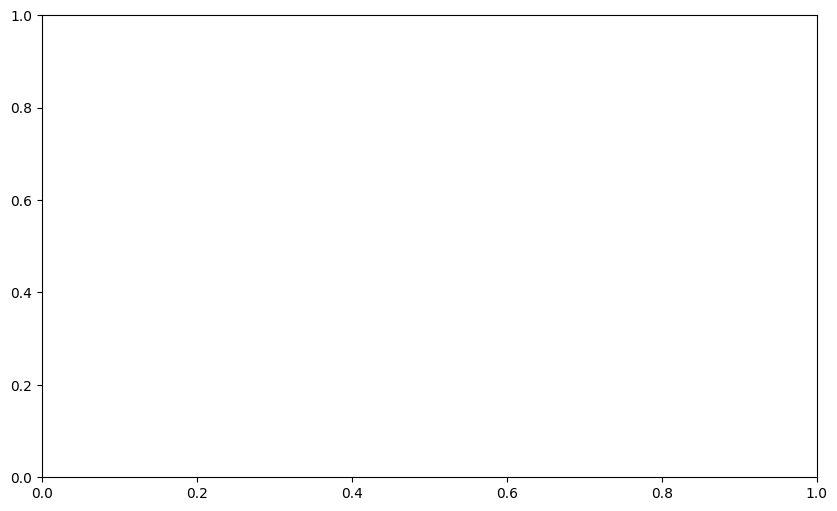

In [ ]:
auroc_stats = (
    layer_df
    .groupby("layer")["auroc"]
    .agg(["mean", "std"])
    .sort_index()
)

auroc_stats.index = (
    auroc_stats.index
    .str.extract(r"(\d+)")
    .astype(int)
    .squeeze()
)

fig, ax = plt.subplots(figsize=(10, 6))

x = auroc_stats.index.to_numpy()

ax.errorbar(
    x,
    auroc_stats["mean"],
    yerr=auroc_stats["std"],
    marker="o",
    capsize=4,
    linewidth=2,
)

ax.set_xlabel("DINO layer")
ax.set_ylabel("Mean AUROC")
ax.set_title("Mean anomaly detection AUROC by DINO layer")
ax.set_xticks(x)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "mean_auroc_layer.svg")
plt.show()

In [ ]:
comparison = (
    layer_df[layer_df["layer"].isin(["layer_11", "layer_12"])]
    .pivot(
        index="category",
        columns="layer",
        values="auroc",
    )
)

comparison["change_12_vs_11"] = (
    comparison["layer_12"] - comparison["layer_11"]
)

comparison.sort_values("change_12_vs_11")

layer,layer_11,layer_12,change_12_vs_11
category,,,
wood,0.986842,0.943860,-0.042982
capsule,0.954527,0.940566,-0.013961
zipper,0.994748,0.987395,-0.007353
hazelnut,0.953571,0.948929,-0.004643
transistor,0.935417,0.935000,-0.000417
tile,1.000000,1.000000,0.000000
leather,1.000000,1.000000,0.000000
bottle,1.000000,1.000000,0.000000
pill,0.943808,0.950355,0.006547
